# Data Science Assessment

**Applicant:** Danish Mahmood Ali

**Email**: danishma309@gmail.com

**Problem Statement:** How attractive would public transport and the Deutschlandticket be for employees commuting to **Johnson & Johnson Medical GmbH, Robert-Koch-Str. 1, 22851 Norderstedt**?

**Approach.**
1. Build a synthetic dataset of 800 employees.
2. Route employees to office based on real HVV GTFS timetable: walk to nearest stop, wait based on transport frequency, ride and transfer based on shortest available path, and walk to the office. A simple car-based time is calculated as a benchmark.
3. Sort employees into commute bands of 30 minutes or less, 31 to 45, 46 to 60, and over 60.
4. Score each person's likelihood of using a Deutschlandticket on a 0 to 100 index. Everyone starts at 100 and loses points for each source of friction: a slower trip than driving, a long journey, transfers, walking, and low frequency. The penalties are set by judgement rather than fitted to data.
5. Report the commute bands, the areas best and worst connected to this site, the areas with the highest adoption potential, and which factors drive the score.

## 0. Environment Setup

In [2]:
#import cells
import os, io, math, zipfile, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from sklearn.neighbors import BallTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap


In [ ]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

N_EMPLOYEES= 800
PEAK_START, PEAK_END= "07:00:00", "09:00:00"
TIME_BIN_EDGES  = [0, 30, 45, 60, np.inf]
TIME_BIN_LABELS = ["<=30 min", "31-45 min", "46-60 min", ">60 min"]

#Router Parameters
WALK_SPEED_M_PER_MIN= 80        # ~4.8 km/h
CAR_SPEED_KMH= 40        # uncongested blended urban/suburban (favours car -> conservative for PT)
ROAD_DETOUR= 1.4       # network vs straight-line factor for driving
TRANSFER_RADIUS_M= 250       # stops within this distance are walk-transferable
TRANSFER_PENALTY_MIN= 4         # fixed penalty per transfer (waiting/reliability)
MAX_WAIT_MIN= 15

WORKPLACE_ADDRESS = "Robert-Koch-Strasse 1, 22851 Norderstedt, Germany"
DATA_DIR = "data"; OUT_DIR = "outputs"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)
GTFS_FILE = f"{DATA_DIR}/hvv_gtfs.zip"
BBOX = (9.55, 53.35, 10.45, 53.90)         # study area: Hamburg + Norderstedt + HVV towns

## 0.1 Data Extraction

We download the current feed of HVV GTFS timetable directly from the Hamburg Transparency Portal.

In [4]:
def fetch_hvv_gtfs(dest=GTFS_FILE):
  """Download the HVV GTFS zip via the Transparenzportal CKAN API. Skips if already present."""
  if os.path.exists(dest):
    print(f"GTFS already downloaded to {dest}")
    return True
  try:
    api= ("https://suche.transparenz.hamburg.de/api/3/action/package_search"
               "?q=gtfs+hvv+fahrplandaten&rows=10")
    for pkg in requests.get(api, timeout=30).json()["result"]["results"]:
      for r in pkg.get("resources",[]):
        url = r.get("url","")
        if url.lower().endswith("zip") and "gtfs" in (r.get("name","")+url).lower():
          print("Download file from ", url)
          with requests.get(url, stream=True, timeout=300) as dl:
            dl.raise_for_status()
            with open(dest,"wb") as f:
              for chunk in dl.iter_content(1 << 20):
                f.write(chunk)
            return True

  except Exception as e:
        print("Download failed:", e)
  return False

fetch_hvv_gtfs()
print("GTFS ready:", GTFS_FILE, f"({os.path.getsize(GTFS_FILE)/1e6:.0f} MB)")

GTFS already downloaded to /content/data/hvv_gtfs.zip
GTFS ready: /content/data/hvv_gtfs.zip (28 MB)


In [5]:
from geopy.geocoders import Nominatim
try:
  loc = Nominatim(user_agent="dticket-commute-study").geocode(WORKPLACE_ADDRESS,timeout=20)
  work_lat, work_long = loc.latitude, loc.longitude
  print("Destination coordinates:({},{})".format(work_lat,work_long))
except Exception as e:
  raise RuntimeError("Geocoding failed:", e)

Destination coordinates:(53.6865222,10.0469639)


## 1. Synthetic Dataset Generation

No real employee data is used. Home locations are sampled from the 7 Hamburg districts and surrounding HVV commuter towns, weighted by residential population. The population figures are approximate and only matter as relative weights.

In [6]:
AREAS = [
    ("Hamburg-Mitte",     53.550, 10.000, 300_000, 3.0),
    ("Altona",            53.550,  9.935, 275_000, 2.5),
    ("Eimsbuettel",       53.575,  9.955, 270_000, 2.0),
    ("Hamburg-Nord",      53.600, 10.000, 315_000, 2.5),
    ("Wandsbek",          53.590, 10.100, 440_000, 3.5),
    ("Bergedorf",         53.490, 10.210, 130_000, 3.0),
    ("Harburg",           53.460,  9.980, 170_000, 3.0),
    ("Norderstedt",       53.708, 10.010,  80_000, 2.0),
    ("Pinneberg",         53.660,  9.800,  43_000, 1.5),
    ("Elmshorn",          53.752,  9.653,  50_000, 1.5),
    ("Ahrensburg",        53.674, 10.240,  34_000, 1.5),
    ("Wedel",             53.583,  9.700,  34_000, 1.5),
    ("Reinbek",           53.510, 10.250,  28_000, 1.5),
    ("Quickborn",         53.730,  9.905,  22_000, 1.3),
    ("Henstedt-Ulzburg",  53.795,  9.980,  28_000, 1.5),
    ("Kaltenkirchen",     53.833,  9.960,  24_000, 1.3),
]
areas = pd.DataFrame(AREAS, columns=["area", "lat", "long", "pop", "sigma_km"])
areas["weight"] = areas['pop']/areas['pop'].sum()

def sample_employees(n, areas, rng):
  """Sample n home locations, area chosen by population weight,
    position scattered around the area centroid with a Gaussian."""
  index = rng.choice(len(areas), size= n, p=areas['weight'].values)
  rows = []
  for i,a in enumerate(index):
    r = areas.iloc[a]
    dlat = rng.normal(0,r.sigma_km/111)
    dlong = rng.normal(0, r.sigma_km / (111.0 * math.cos(math.radians(r.lat))))
    rows.append((f"EMP_{i:04d}",r.area, r.lat+dlat, r.long+dlong))
  df = pd.DataFrame(rows, columns=["id","name", "lat", "long"])
  return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.long, df.lat), crs="EPSG:4326")


emp = sample_employees(N_EMPLOYEES, areas, rng)
print(f"{len(emp)} synthetic employees across {emp.name.nunique()} areas")
emp.groupby("name").size().sort_values(ascending=False).to_frame("emp").T


800 synthetic employees across 16 areas


name,Wandsbek,Hamburg-Mitte,Hamburg-Nord,Altona,Eimsbuettel,Harburg,Bergedorf,Norderstedt,Elmshorn,Ahrensburg,Pinneberg,Henstedt-Ulzburg,Reinbek,Kaltenkirchen,Quickborn,Wedel
emp,152,117,112,97,94,75,38,28,18,17,12,10,10,8,6,6


## 2. Load GTFS & Assess Public-Transport Connectivity

We load the GTFS timetable and select a valid weekday within the feed's calendar. Each employee's home is then checked for proximity to serviced stops: distance to the nearest one and the number of departures per hour within 600 m during the morning peak.

In [7]:
def load_gtfs(path):
  """Read the needed GTFS tables from the zip. Skips tables that exist but are empty."""
  tables={}
  with zipfile.ZipFile(path) as zf:
    for name in ["stops","trips","stop_times","calendar","calendar_dates"]:
      hit = [n for n in zf.namelist() if os.path.basename(n)== f"{name}.txt"]
      if hit:
        raw = zf.read(hit[0]).decode("utf-8","ignore")
        if len([ln for ln in raw.splitlines() if ln.strip()]) >1:
          tables[name] = pd.read_csv(io.StringIO(raw), dtype=str)
  return tables

gtfs = load_gtfs(GTFS_FILE)
stops, trips, stop_time = gtfs['stops'], gtfs['trips'], gtfs['stop_times']
calendar, calendar_dates = gtfs.get('calendar'), gtfs.get('calendar_dates')
stops['stops_lat']= stops.stop_lat.astype(float)
stops['stops_long']= stops.stop_lon.astype(float)
print(f"GTFS summary: {len(stops):,} stops | {len(trips):,} trips | {len(stop_time):,} stop_times")

GTFS summary: 16,747 stops | 83,278 trips | 1,708,946 stop_times


In [8]:
def pick_date(calendar,calendar_dates):
  """Pick a weekday near the middle of the feed's validity window."""
  if calendar is not None:
    start = pd.to_datetime(calendar.start_date, format="%Y%m%d").min()
    end = pd.to_datetime(calendar.end_date, format="%Y%m%d").max()
  else:
    d= pd.to_datetime(calendar_dates.date, format="%Y%m%d")
    start = d.min()
    end = d.max()
  day = start + (end - start)/2
  day += pd.Timedelta(days=(1 - day.weekday()) % 7)
  if day > end: day -= pd.Timedelta(days=7)
  return day.normalize()

def active_services(day, calendar,calendar_dates):
  """Resolve service_ids running on the given date, applying calendar_dates exceptions."""
  ymd = day.strftime("%Y%m%d")
  wc = day.day_name().lower()
  active = set()
  if calendar is not None:
        m = (calendar.start_date <= ymd) & (calendar.end_date >= ymd) & (calendar[wc] == "1")
        active |= set(calendar.loc[m, "service_id"])
  if calendar_dates is not None:
        ex = calendar_dates[calendar_dates.date == ymd]
        active |= set(ex.loc[ex.exception_type == "1", "service_id"])
        active -= set(ex.loc[ex.exception_type == "2", "service_id"])
  return active


ANALYSIS_DATE = pick_date(calendar, calendar_dates)
services = active_services(ANALYSIS_DATE, calendar, calendar_dates)
print(f"Analysis date: {ANALYSIS_DATE.date()} ({ANALYSIS_DATE.day_name()}) | active services: {len(services):,}")
assert services, "No active services on this date - inspect the feed's calendar files."

Analysis date: 2024-12-10 (Tuesday) | active services: 96


In [9]:
def to_min(s):
  """GTFS time string to minutes. Handles missing seconds, padding, and times past 24:00."""
  if not isinstance(s,str): return np.nan
  p= s.strip().split(":")
  if len(p) < 2: return np.nan
  try:
      return int(p[0])*60 + int(p[1]) + (int(p[2])/60 if len(p) > 2 else 0)
  except Exception:
      return np.nan

for c in ["trip_id", "service_id"]:
    if c in trips:      trips[c] = trips[c].astype(str).str.strip()
for c in ["trip_id", "stop_id", "departure_time", "arrival_time", "stop_sequence"]:
    if c in stop_time: stop_time[c] = stop_time[c].astype(str).str.strip()
services = {str(s).strip() for s in services}

act_trips = set(trips.loc[trips.service_id.isin(services), "trip_id"])
act_st = stop_time[stop_time.trip_id.isin(act_trips)].copy()
act_st["dep_min"] = act_st.departure_time.map(to_min)
act_st["arr_min"] = act_st.arrival_time.map(to_min)
act_st["stop_sequence"] = pd.to_numeric(act_st.stop_sequence, errors="coerce")
act_st = act_st.dropna(subset=["dep_min", "arr_min", "stop_sequence"])
print(f"active trips: {len(act_trips):,} | stop_time rows on those trips: {len(act_st):,}")

PEAK_LO, PEAK_HI = 7*60, 9*60
peak = act_st[(act_st.dep_min >= PEAK_LO) & (act_st.dep_min < PEAK_HI)]
print(f"stop_time in peak hours:  {len(peak):,}")
if len(peak)==0:
  peak = act_st

dep_per_stop = peak.groupby("stop_id").size().rename("peak_deps")
stops["stops_id"] = stops.stop_id.astype(str).str.strip()
stops = stops.drop(columns=["peak_deps"],errors="ignore").merge(
    dep_per_stop, left_on="stops_id", right_index=True, how="left").fillna({"peak_deps": 0})
serviced = stops[stops.peak_deps > 0].reset_index(drop=True)
print(f"active stops: {len(serviced):,}")

active trips: 44,012 | stop_time rows on those trips: 882,663
stop_time in peak hours:  119,004
active stops: 15,055


In [10]:
EARTH_M = 6_371_000
serviced[["stop_lat", "stop_lon"]] = serviced[["stop_lat", "stop_lon"]].astype(float)
emp[["lat", "lon"]] = emp[["lat", "long"]].astype(float)
serv_rad = np.radians(serviced[["stop_lat", "stop_lon"]].values)
emp_rad  = np.radians(emp[["lat", "lon"]].values)
tree = BallTree(serv_rad, metric="haversine")

dist, idx = tree.query(emp_rad, k=1)
emp["nearest_stop_m"]    = dist[:, 0] * EARTH_M
emp["nearest_stop_name"] = serviced.iloc[idx[:, 0]].stop_name.values
emp["board_serv_idx"]    = idx[:, 0]                     # index into `serviced`

within = tree.query_radius(emp_rad, r=600 / EARTH_M)
emp["freq_per_h"] = [serviced.iloc[w].peak_deps.sum() / 2 for w in within]
print(emp[["nearest_stop_m", "freq_per_h"]].describe().round(1))

       nearest_stop_m  freq_per_h
count           800.0       800.0
mean            279.5        95.6
std             226.7       106.0
min               6.8         0.0
25%             133.8        15.0
50%             212.4        71.0
75%             348.1       139.5
max            1415.9       853.0


## 3. Door-to-Door Commute Time

  We build a directed graph over the serviced stops. Ride edges connect consecutive stops on each trip, weighted by the scheduled travel time between them. Transfer edges connect stops within 250 m, weighted by walk time plus a 4-minute penalty.

  Dijkstra runs once on the reversed graph from the stop nearest the office. That gives the in-vehicle-plus-transfer time from every other stop to work. Each employee's total is then:

`access walk + wait (half headway, capped at 15 min) + in-vehicle/transfers + egress walk `

Car times use a simple geometric model: straight-line distance times 1.4, divided by 40 km/h. This is used as a baseline.

In [11]:
act_st = act_st.sort_values(["trip_id","stop_sequence"])
grp = act_st.groupby("trip_id",sort=False)
prev_stop = grp["stop_id"].shift()
prev_dep  = grp["dep_min"].shift()
ride = pd.DataFrame({"u": prev_stop, "v": act_st.stop_id, "w": act_st.arr_min - prev_dep}).dropna()
ride = ride[(ride.w > 0) & (ride.w < 180)]
ride = ride.groupby(["u", "v"], as_index=False).w.min()
print(f"Unique rides: {len(ride):,}")

Unique rides: 24,707


In [12]:
pairs = tree.query_radius(serv_rad, r=TRANSFER_RADIUS_M / EARTH_M)
tu,tv,tw = [],[],[]
sid = serviced.stop_id.values
for i, nb in enumerate(pairs):
  for j in nb:
    if i != j:
      d_m = np.arccos(np.clip(np.sin(serv_rad[i,0])*np.sin(serv_rad[j,0]) +
                    np.cos(serv_rad[i,0])*np.cos(serv_rad[j,0])*np.cos(serv_rad[i,1]-serv_rad[j,1]),-1,1))*EARTH_M
      tu.append(sid[i]);
      tv.append(sid[j]);
      tw.append(d_m/WALK_SPEED_M_PER_MIN + TRANSFER_PENALTY_MIN)
transfer = pd.DataFrame({"u": tu, "v": tv, "w": tw})
print(f"Unique transfers: {len(transfer):,}")

stop_to_ix = {s: k for k, s in enumerate(serviced.stop_id)}
ride_k     = ride.copy();     ride_k["kind"]     = "ride"
transfer_k = transfer.copy(); transfer_k["kind"] = "transfer"

edges = pd.concat([ride_k, transfer_k], ignore_index=True)
edges = edges[edges.u.isin(stop_to_ix) & edges.v.isin(stop_to_ix)]
# fastest option wins per stop pair (a ride normally beats a walk transfer)
edges = edges.sort_values("w").drop_duplicates(subset=["u", "v"], keep="first").reset_index(drop=True)

ui = edges.u.map(stop_to_ix).values
vi = edges.v.map(stop_to_ix).values
n  = len(serviced)
G  = coo_matrix((edges.w.values, (ui, vi)), shape=(n, n)).tocsr()
assert G.nnz == len(edges), "duplicate (u,v) pairs still being summed"

is_tr = edges.kind.values == "transfer"
transfer_edges = set(zip(ui[is_tr].tolist(), vi[is_tr].tolist()))

station_key = serviced.get("parent_station", pd.Series(index=serviced.index, dtype=object))
station_key = station_key.replace("", np.nan).fillna(serviced.stop_name).values

print(f"graph: {G.shape}, nnz = {G.nnz:,}  (= {len(edges):,} edges, no duplicates)")
print(f"transfer edges: {len(transfer_edges):,} | distinct stations: {pd.unique(station_key).size:,} "
      f"from {len(serviced):,} stop records")

Unique transfers: 29,880
graph: (15055, 15055), nnz = 49,904  (= 49,904 edges, no duplicates)
transfer edges: 27,968 | distinct stations: 8,711 from 15,055 stop records


In [13]:
work_pt = np.radians([[work_lat, work_long]])
_, wix = BallTree(serv_rad, metric="haversine").query(work_pt, k=1)
work_ix = int(wix[0,0])
work_stop = serviced.iloc[work_ix]

egress_min = (np.arccos(np.clip(
    np.sin(math.radians(work_lat))*np.sin(serv_rad[work_ix,0]) +
    np.cos(math.radians(work_lat))*np.cos(serv_rad[work_ix,0])*np.cos(math.radians(work_long)-serv_rad[work_ix,1]),
    -1,1))*EARTH_M) / WALK_SPEED_M_PER_MIN
print(f"Office nearest stop: {work_stop.stop_name} (egress walk {egress_min:.1f} min)")

transit, pred = dijkstra(G.T.tocsr(), directed=True, indices=work_ix, return_predecessors=True)

def path_transfers(k, max_hops=500):
    """Walk the predecessor chain from stop k back to the office stop."""
    k = int(k)
    if k == work_ix:
        return 0, 0
    between = same = 0
    cur, hops = k, 0
    while cur != work_ix and hops < max_hops:
        p = int(pred[cur])
        if p < 0:
            return np.nan, np.nan                    # no path
        if (cur, p) in transfer_edges:               # edge in G runs cur -> p
            if station_key[cur] != station_key[p]:
                between += 1
            else:
                same += 1                            # platform/direction change at one station
        cur, hops = p, hops + 1
    if cur != work_ix:
        return np.nan, np.nan
    return between, between + same

_cache = {}
def _transfers(k):
    k = int(k)
    if k not in _cache:
        _cache[k] = path_transfers(k)
    return _cache[k]

_res = [ _transfers(k) for k in emp.board_serv_idx ]
emp["transfers"]                = [r[0] for r in _res]
emp["transfers_incl_platform"]  = [r[1] for r in _res]

print("between-station transfers (used for scoring):")
print(emp.transfers.value_counts(dropna=False).sort_index().to_string())
print(f"\nmean between-station: {emp.transfers.mean():.2f} "
      f"| mean incl. platform changes: {emp.transfers_incl_platform.mean():.2f}")
print(f"employees with a routable path: {emp.transfers.notna().sum()}/{len(emp)}")

Office nearest stop: Glashütte, Robert-Koch-Straße (West) (egress walk 0.8 min)
between-station transfers (used for scoring):
transfers
0.0    267
1.0     71
2.0    399
3.0     54
4.0      5
NaN      4

mean between-station: 1.32 | mean incl. platform changes: 2.21
employees with a routable path: 796/800


In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    p1, p2 = map(math.radians, (lat1, lat2)); dl = math.radians(lon2 - lon1)
    a = math.sin((p2 - p1) / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * 6371 * math.asin(math.sqrt(a))

emp["car_min"] = [haversine_km(r.lat, r.lon, work_lat, work_long) * ROAD_DETOUR / CAR_SPEED_KMH * 60
                  for r in emp.itertuples()]

board_ix         = emp.board_serv_idx.astype(int).values
board_deps_per_h = serviced.peak_deps.values[board_ix] / 2.0
n_fallback = (emp.freq_per_h == 0).sum()
emp["freq_per_h"] = emp.freq_per_h.where(emp.freq_per_h > 0, board_deps_per_h)
print(f"homes with no stop within 600 m, using boarding-stop frequency instead: {n_fallback}")

access_min = emp.nearest_stop_m / WALK_SPEED_M_PER_MIN
wait_min   = np.minimum(0.5 * (60 / emp.freq_per_h), MAX_WAIT_MIN)
invehicle  = emp.board_serv_idx.map(lambda k: transit[int(k)])

emp["walk_min"] = access_min + egress_min
emp["pt_min"]   = access_min + wait_min + invehicle + egress_min
emp.loc[~np.isfinite(emp.pt_min), "pt_min"] = np.nan

emp["pt_min_filled"] = emp.pt_min.fillna(999)
emp["time_band"] = pd.cut(emp.pt_min_filled, bins=TIME_BIN_EDGES, labels=TIME_BIN_LABELS, right=True)

print(f"reachable by public transport: {emp.pt_min.notna().sum()}/{len(emp)}")
display(emp[["pt_min", "car_min", "walk_min", "freq_per_h", "transfers"]].describe().round(1))
print(emp.time_band.value_counts(normalize=True).reindex(TIME_BIN_LABELS).mul(100).round(1).to_string())

homes with no stop within 600 m, using boarding-stop frequency instead: 79
reachable by public transport: 796/800


,pt_min,car_min,walk_min,freq_per_h,transfers
count,796.0,800.0,800.0,800.0,796.0
mean,56.6,32.7,4.3,96.1,1.3
std,16.5,13.0,2.8,105.6,1.0
min,17.4,2.4,0.9,0.5,0.0
25%,45.8,24.1,2.5,15.0,0.0
50%,53.7,30.5,3.5,71.0,2.0
75%,67.4,40.2,5.2,139.5,2.0
max,109.1,68.3,18.5,853.0,4.0


time_band
<=30 min      4.5
31-45 min    18.2
46-60 min    40.6
>60 min      36.6


## 4. Deutschlandticket Adoption Index (0–100)

Each employee starts at 100 and loses points for friction. This follows the shape of a standard generalized-cost function from transport economics.

| Factor | Logic | Penalty |
|---|---|---|
| Base | everyone starts here | 100 |
| PT vs car gap | per minute PT is slower than driving | −1 / min |
| Absolute PT time | per minute beyond 45 min | −0.5 / min |
| Transfers | per transfer | −10 |
| Walking | per minute of total walk beyond 10 min | −2 / min |
| Frequency | per departure/hour below 8 | −2 |

Final scores are clipped between 0 and 100. Employees with no viable public transport are given 0.


Cost is not factored in as Deutschland ticket would generally be cheaper than commuting with car, so it would not have an effect as it'll apply to all employees.

In [15]:
# ---- Penalty parameters ----
ABS_FREE_MIN  = 45      # minutes of commute tolerated before the absolute-time penalty starts
WALK_FREE_MIN = 10      # total walking tolerated before the walk penalty starts
FREQ_TARGET   = 8       # departures/hour considered "turn-up-and-go"

P_GAP, P_ABS, P_TRANSFER, P_WALK, P_FREQ = 1.0, 0.5, 10.0, 2.0, 2.0

def adoption_index(df, p_gap=P_GAP, p_abs=P_ABS, p_tr=P_TRANSFER,
                   p_walk=P_WALK, p_freq=P_FREQ):
    """0-100 score to judge Deutschland ticket adoption"""
    gap        = (df.pt_min - df.car_min).clip(lower=0)
    over_time  = (df.pt_min - ABS_FREE_MIN).clip(lower=0)
    over_walk  = (df.walk_min - WALK_FREE_MIN).clip(lower=0)
    freq_short = (FREQ_TARGET - df.freq_per_h).clip(lower=0)
    transfers  = df.transfers.fillna(3)
    score = (100
             - p_gap  * gap
             - p_abs  * over_time
             - p_tr   * transfers
             - p_walk * over_walk
             - p_freq * freq_short)
    return score.clip(0, 100).where(df.pt_min.notna(), 0)

emp["adoption_index"] = adoption_index(emp)
emp["likely_adopter"] = emp.adoption_index >= 60

print(emp.adoption_index.describe().round(1).to_string())
print(f"\nLikely adopters (index >= 60): {emp.likely_adopter.sum()} of {len(emp)} "
      f"({emp.likely_adopter.mean():.1%})")

count    800.0
mean      55.0
std       22.0
min        0.0
25%       44.5
50%       57.7
75%       73.1
max       92.6

Likely adopters (index >= 60): 354 of 800 (44.2%)


In [16]:
m = emp.pt_min.notna()
breakdown = {
    "PT slower than car":  ((emp.pt_min - emp.car_min).clip(lower=0) * P_GAP),
    "Commute over 45 min": ((emp.pt_min - ABS_FREE_MIN).clip(lower=0) * P_ABS),
    "Transfers":           (emp.transfers.fillna(3) * P_TRANSFER),
    "Walking over 10 min": ((emp.walk_min - WALK_FREE_MIN).clip(lower=0) * P_WALK),
    "Frequency under 8/h": ((FREQ_TARGET - emp.freq_per_h).clip(lower=0) * P_FREQ),
}
tbl = pd.DataFrame({
    "avg points lost": {k: v[m].mean() for k, v in breakdown.items()},
    "% of employees affected": {k: (v[m] > 0).mean() * 100 for k, v in breakdown.items()},
}).round(1).sort_values("avg points lost", ascending=False)
display(tbl)

,avg points lost,% of employees affected
PT slower than car,23.8,99.9
Transfers,13.2,66.5
Commute over 45 min,6.7,77.1
Frequency under 8/h,1.2,14.8
Walking over 10 min,0.3,5.4


In [17]:
rows = []
for tr in (5, 10, 15):
    for gp in (0.5, 1.0, 1.5):
        s = adoption_index(emp, p_gap=gp, p_tr=tr)
        rows.append({"transfer penalty": tr, "gap penalty": gp,
                     "mean index": round(s.mean(), 1),
                     "% >= 60": round((s >= 60).mean() * 100, 1)})
sens = pd.DataFrame(rows)
display(sens)

base_rank = emp.groupby("name").adoption_index.mean().rank(ascending=False)
alt_rank  = (emp.assign(alt=adoption_index(emp, p_gap=1.5, p_tr=5))
               .groupby("name").alt.mean().rank(ascending=False))
print(f"\nSpearman correlation of area rankings under very different weights: "
      f"{base_rank.corr(alt_rank, method='spearman'):.3f}")
print("-> Rankings are stable; only the absolute level shifts.")

,transfer penalty,gap penalty,mean index,% >= 60
0,5,0.5,72.9,84.0
1,5,1.0,61.2,63.9
2,5,1.5,50.3,40.0
3,10,0.5,66.3,68.9
4,10,1.0,55.0,44.2
5,10,1.5,44.5,28.2
6,15,0.5,60.0,45.9
7,15,1.0,49.1,35.1
8,15,1.5,39.1,25.9



Spearman correlation of area rankings under very different weights: 0.826
-> Rankings are stable; only the absolute level shifts.


## 5. Summary findings

Share per commute band, overall adoption potential, the areas best and worst connected to this site, the areas with the highest and lowest adoption potential, and the factors that move the score most.

In [18]:
cum = emp.pt_min_filled
summary = pd.DataFrame({
    "Employees within 30 min":            f"{(cum <= 30).mean():.1%}",
    "Employees within 45 min":            f"{(cum <= 45).mean():.1%}",
    "Employees within 60 min":            f"{(cum <= 60).mean():.1%}",
    "Employees over 60 min / no PT":      f"{(cum >  60).mean():.1%}",
    "Mean adoption index (0-100)":        f"{emp.adoption_index.mean():.1f}",
    "Likely adopters (index >= 60)":      f"{emp.likely_adopter.mean():.1%}",
    "Median PT commute (reachable)":      f"{emp.pt_min.median():.0f} min",
    "Median car commute":                 f"{emp.car_min.median():.0f} min",
}, index=["Value"]).T
display(summary)

,Value
Employees within 30 min,4.5%
Employees within 45 min,22.8%
Employees within 60 min,63.4%
Employees over 60 min / no PT,36.6%
Mean adoption index (0-100),55.0
Likely adopters (index >= 60),44.2%
Median PT commute (reachable),54 min
Median car commute,30 min


In [19]:
by_area = (emp.groupby("name")
             .agg(employees=("id", "size"),
                  median_pt_min=("pt_min", "median"),
                  median_car_min=("car_min", "median"),
                  pct_within_45=("pt_min_filled", lambda s: (s <= 45).mean() * 100),
                  mean_transfers=("transfers", "mean"),
                  mean_index=("adoption_index", "mean"))
             .round(1).sort_values("mean_index", ascending=False))
display(by_area)

conn = by_area.sort_values("median_pt_min")
print("BEST connected TO THIS SITE:", ", ".join(conn.head(4).index))
print("WORST connected TO THIS SITE:", ", ".join(conn.tail(4).index))

adopt = by_area.sort_values("mean_index", ascending=False)
print("HIGHEST adoption potential:", ", ".join(adopt.head(4).index))
print("LOWEST adoption potential:", ", ".join(adopt.tail(4).index))

,employees,median_pt_min,median_car_min,pct_within_45,mean_transfers,mean_index
name,,,,,,
Hamburg-Nord,112,43.2,22.7,60.7,0.6,71.0
Pinneberg,12,57.3,34.0,8.3,0.2,67.9
Norderstedt,28,30.5,8.4,82.1,0.0,67.4
Quickborn,6,51.9,22.0,16.7,0.0,62.9
Henstedt-Ulzburg,10,47.8,26.6,30.0,0.3,62.6
Eimsbuettel,94,52.3,29.1,7.4,0.9,62.3
Ahrensburg,17,50.1,27.6,17.6,0.5,61.9
Wandsbek,152,46.8,24.7,40.1,1.2,61.7
Kaltenkirchen,8,53.0,35.5,12.5,1.5,58.4


BEST connected TO THIS SITE: Norderstedt, Hamburg-Nord, Wandsbek, Henstedt-Ulzburg
WORST connected TO THIS SITE: Reinbek, Harburg, Elmshorn, Wedel
HIGHEST adoption potential: Hamburg-Nord, Pinneberg, Norderstedt, Quickborn
LOWEST adoption potential: Reinbek, Elmshorn, Altona, Harburg


In [20]:
drivers = {
    "Shorter door-to-door PT time": -emp.pt_min,
    "Smaller PT-minus-car gap":     -(emp.pt_min - emp.car_min),
    "Fewer transfers":              -emp.transfers,
    "Less walking":                 -emp.walk_min,
    "Higher service frequency":      emp.freq_per_h,
}
corr = (pd.Series({k: v.corr(emp.adoption_index) for k, v in drivers.items()})
          .sort_values(ascending=False).round(2).to_frame("corr. with adoption index"))
display(corr)

,corr. with adoption index
Shorter door-to-door PT time,0.88
Smaller PT-minus-car gap,0.77
Fewer transfers,0.74
Less walking,0.50
Higher service frequency,0.34


## 6. Charts

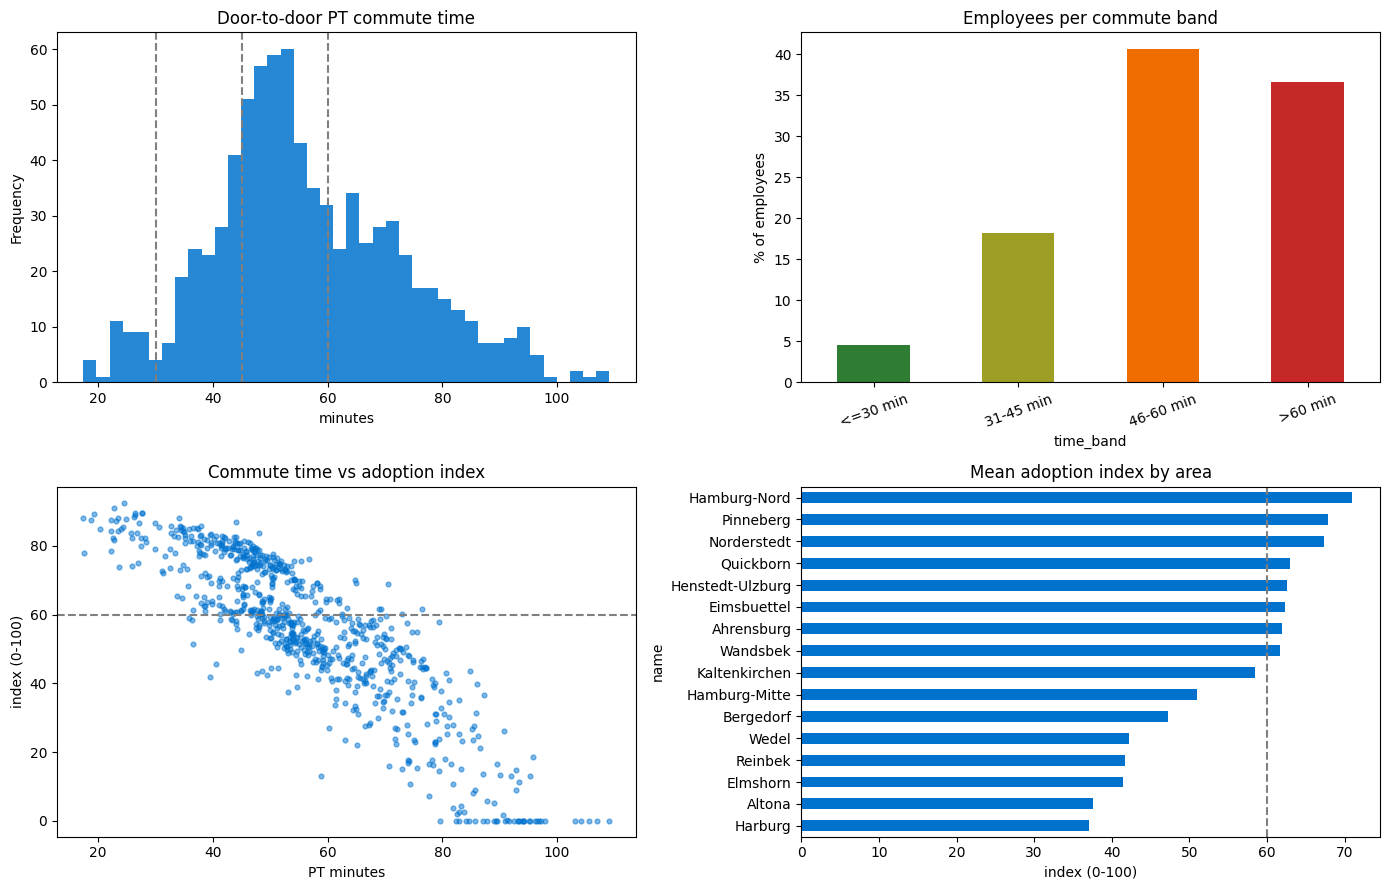

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

emp.pt_min.dropna().plot.hist(bins=40, ax=ax[0, 0], color="#0072CE", alpha=.85)
for x in (30, 45, 60):
    ax[0, 0].axvline(x, ls="--", c="grey")
ax[0, 0].set(title="Door-to-door PT commute time", xlabel="minutes")

(emp.time_band.value_counts().reindex(TIME_BIN_LABELS) / len(emp) * 100).plot.bar(
    ax=ax[0, 1], color=["#2e7d32", "#9e9d24", "#ef6c00", "#c62828"])
ax[0, 1].set(title="Employees per commute band", ylabel="% of employees")
ax[0, 1].tick_params(axis="x", rotation=20)

ax[1, 0].scatter(emp.pt_min, emp.adoption_index, s=12, alpha=.5, c="#0072CE")
ax[1, 0].set(title="Commute time vs adoption index", xlabel="PT minutes", ylabel="index (0-100)")
ax[1, 0].axhline(60, ls="--", c="grey")

by_area.mean_index.sort_values().plot.barh(ax=ax[1, 1], color="#0072CE")
ax[1, 1].set(title="Mean adoption index by area", xlabel="index (0-100)")
ax[1, 1].axvline(60, ls="--", c="grey")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/summary_charts.png", dpi=150)
plt.show()

## 7. Interactive map

In [ ]:
BAND_COLOR = dict(zip(TIME_BIN_LABELS, ["#2e7d32", "#9e9d24", "#ef6c00", "#c62828"]))

m = folium.Map(location=[work_lat, work_long], zoom_start=10, tiles="cartodbpositron")
folium.Marker([work_lat, work_long], tooltip="J&J Medical GmbH, Norderstedt",
              icon=folium.Icon(color="blue", icon="briefcase", prefix="fa")).add_to(m)

fg = folium.FeatureGroup(name="Employees by commute band").add_to(m)
for r in emp.itertuples():
    pt = "no viable PT" if pd.isna(r.pt_min) else f"{r.pt_min:.0f} min"
    tr = "-" if pd.isna(r.transfers) else f"{r.transfers:.0f}"
    folium.CircleMarker(
        [r.lat, r.lon], radius=3, weight=0, fill=True, fill_opacity=.75,
        fill_color=BAND_COLOR[str(r.time_band)],
        tooltip=f"{r.id} | {r.name}<br>PT: {pt} | transfers: {tr}<br>index: {r.adoption_index:.0f}"
    ).add_to(fg)

HeatMap(emp.loc[emp.likely_adopter, ["lat", "lon"]].values.tolist(),
        name="High-potential adopters", radius=18).add_to(m)

folium.LayerControl().add_to(m)
m.save(f"{OUT_DIR}/commute_map.html")
print(f"Map saved to {OUT_DIR}/commute_map.html")
m

Map saved to data/commute_map.html


## 8. Conclusions, limitations

Areas at the top of the adoption ranking are where the Deutschlandticket works
best. Areas at the bottom need help before public transport becomes realistic.

Limitations:


*   Synthetic data generated instead of real life data
*   Routing is done using a timetable graph rather than a full engine like R5 or OpenTripPlanner.
*  Car times are uncongested, which may not reflect real life scenarios in most cases.
*  Adoption scoring is based on judgement rather than fitted to data.
*  GTFS feed is dated to December 2024.



In [ ]:
cols = ["id", "name", "lat", "lon", "nearest_stop_name", "nearest_stop_m", "freq_per_h",
        "walk_min", "transfers", "pt_min", "car_min", "time_band",
        "adoption_index", "likely_adopter"]
emp[cols].to_csv(f"{OUT_DIR}/employee_results.csv", index=False)
by_area.to_csv(f"{OUT_DIR}/area_summary.csv")
print("Saved employee_results.csv and area_summary.csv")

Saved employee_results.csv and area_summary.csv
